In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np

In [3]:
# exploring dataset
data = pd.read_csv("sante_cameroun.csv")

data = pd.DataFrame(data)
data.head()

,revenu_moyen,acces_sante,taux_vaccination,nombre_medecins,pollution,taux_mortalite_infantile
0,362178.083193,71.362532,37.218671,5,10.243981,6.399233
1,765500.014487,26.731197,93.178703,18,20.502646,-5.445790
2,612395.759268,32.930297,65.367666,28,52.584958,18.692372
3,519060.938938,91.884335,87.852023,10,64.549169,-7.321043
4,209213.048310,68.514325,52.403472,29,81.486050,31.123201


In [ ]:
# checking the structure of the dataset
data.shape # (200,6)

data.dtypes # All the data tyoes are correct

data.isna().sum() # No missing values in the dataset

data.duplicated().sum() # No duplicated values in the dataset

np.int64(0)

In [11]:
# desciptive statistics
data.info()
data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   revenu_moyen              200 non-null    float64
 1   acces_sante               200 non-null    float64
 2   taux_vaccination          200 non-null    float64
 3   nombre_medecins           200 non-null    int64  
 4   pollution                 200 non-null    float64
 5   taux_mortalite_infantile  200 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 9.5 KB


,revenu_moyen,acces_sante,taux_vaccination,nombre_medecins,pollution,taux_mortalite_infantile
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,438804.363287,60.350011,66.447095,14.520000,57.316657,10.998902
std,206424.001822,23.440095,21.511616,8.328048,24.560957,13.695900
min,103865.481987,20.404927,30.758636,1.000000,10.243981,-21.884364
25%,260007.690328,40.917000,47.886422,6.000000,37.996069,1.410570
50%,446140.377266,63.331190,66.777963,14.500000,58.583876,10.577949
75%,629801.731243,79.375945,86.778042,22.000000,78.158399,20.679103
max,790820.855620,99.240411,99.980237,29.000000,99.792335,45.138154


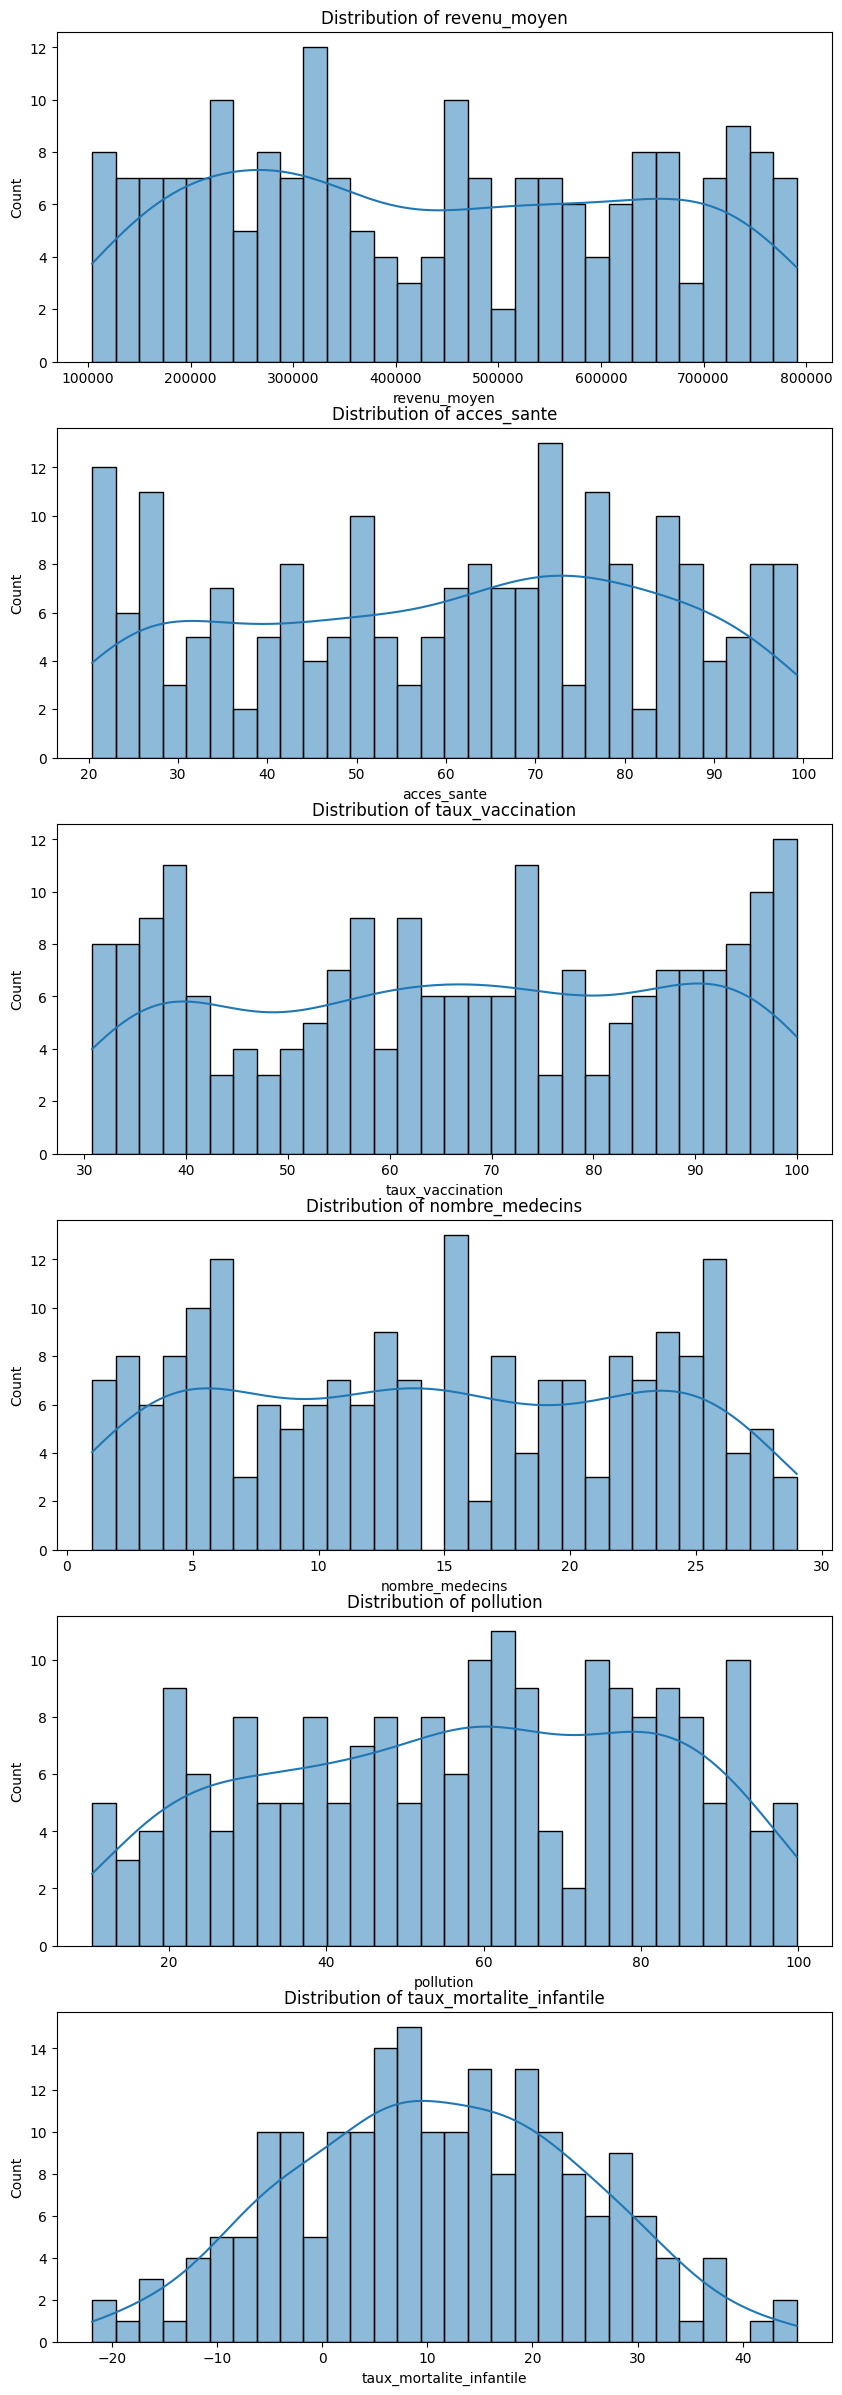

In [14]:
#  univariate analysis

plt.figure(figsize=(10, 5 * len(data.columns)))
# 1. Histograms
for i, col in enumerate(data.columns):
    plt.subplot(len(data.columns), 1, i+1)
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')

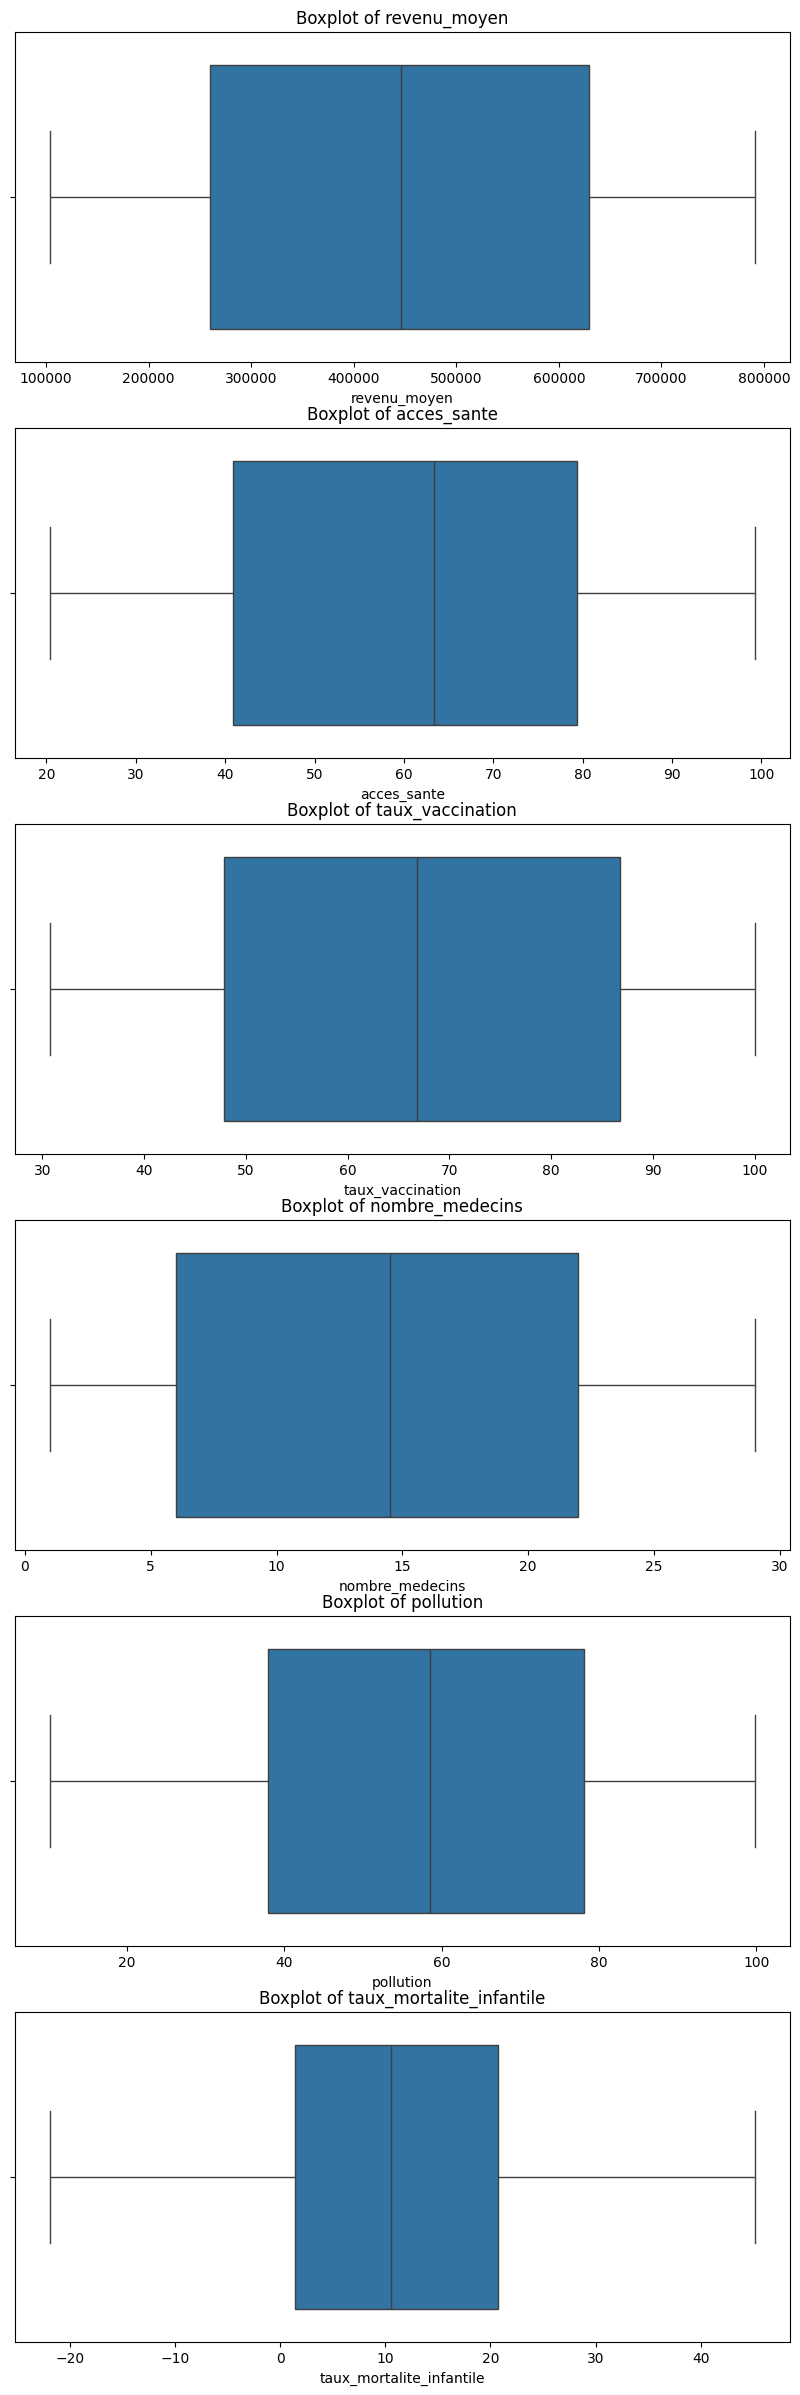

In [ ]:
# 2. Boxplots (No outliers in the dataset)
plt.figure(figsize=(10, 5 * len(data.columns)))
for i, col in enumerate(data.columns):  
    plt.subplot(len(data.columns), 1, i+1)
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')

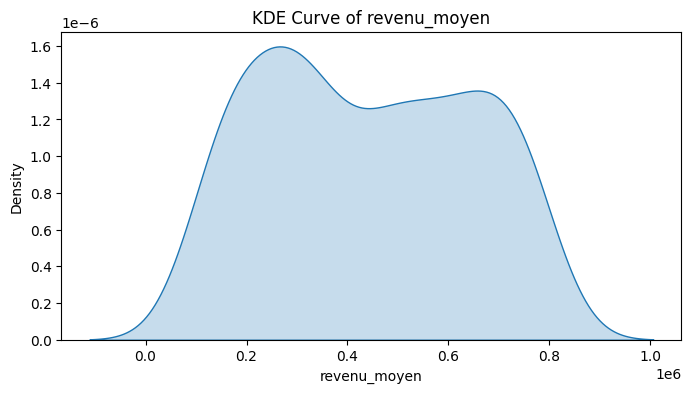

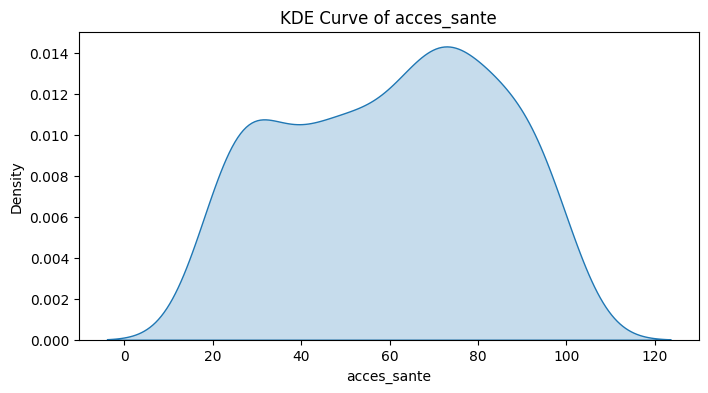

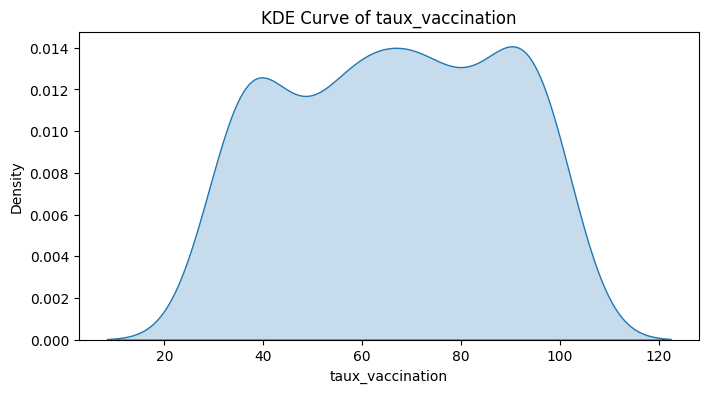

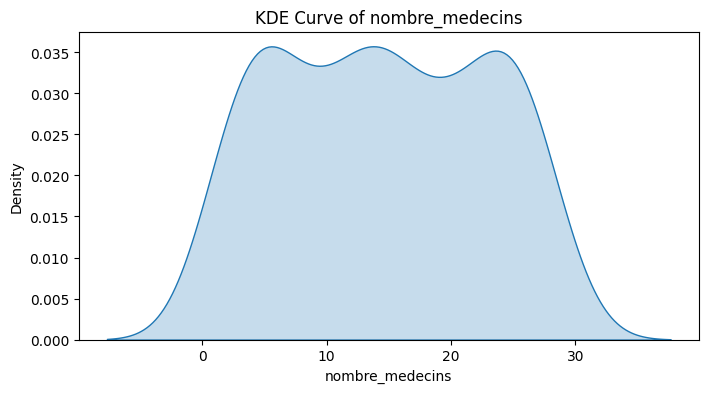

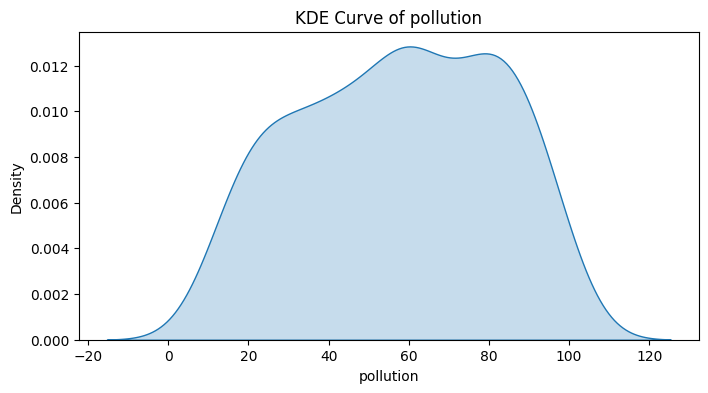

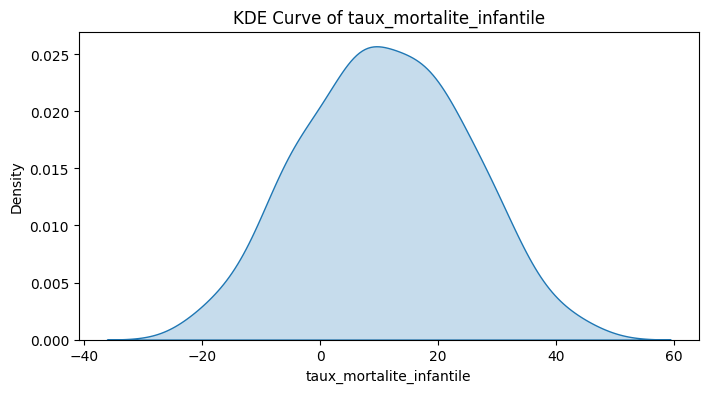

In [16]:
# 3. KDE curves
for col in data.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(8,4))
    sns.kdeplot(data[col], fill=True)
    plt.title(f'KDE Curve of {col}')
    plt.show()

In [ ]:
# 4. Calculating Skewness
for col in data.select_dtypes(include=np.number).columns:
    skewness = data[col].skew()

    print(f"{col}: Skewness = {skewness}")

revenu_moyen: Skewness = 0.08630682037359141
acces_sante: Skewness = -0.12921784037623565
taux_vaccination: Skewness = -0.06879911525186597
nombre_medecins: Skewness = 0.020834939524566047
pollution: Skewness = -0.1320923892046425
taux_mortalite_infantile: Skewness = 0.011203910714664023


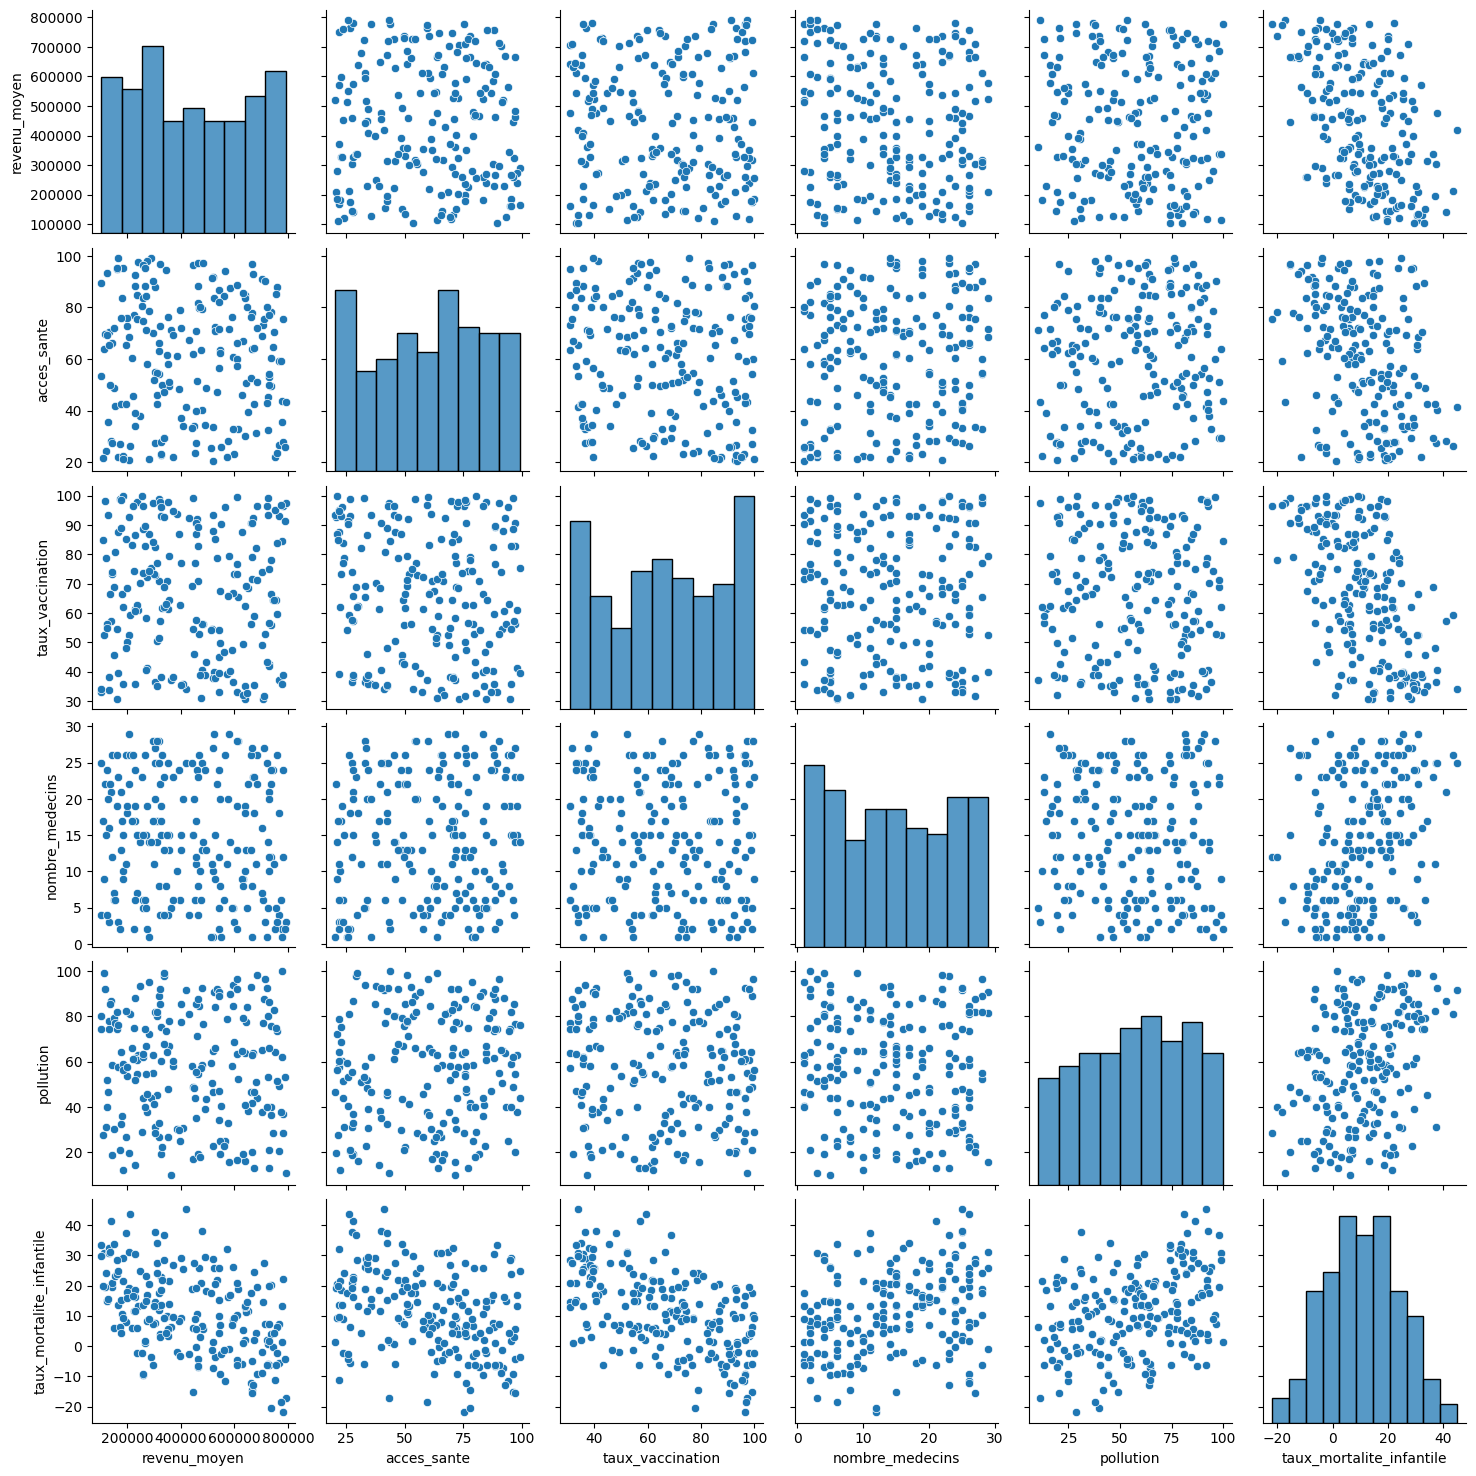

In [19]:
# Bivariate analysis
# 1. Scatter Plots
sns.pairplot(data)
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

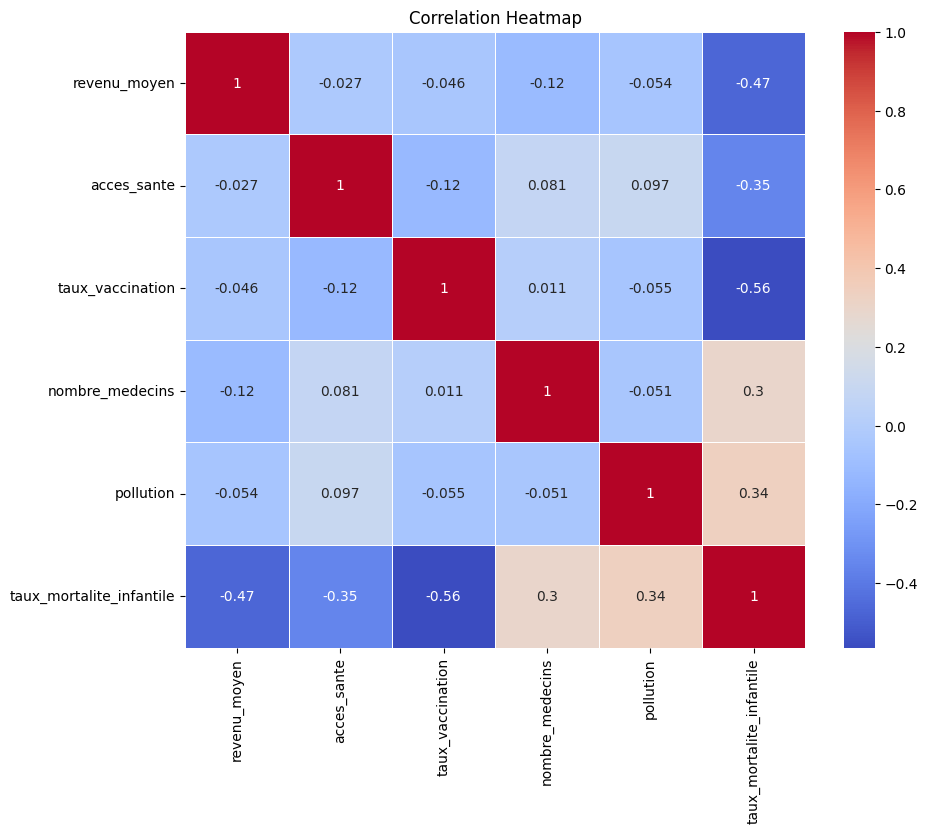

In [20]:
# 2. correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')

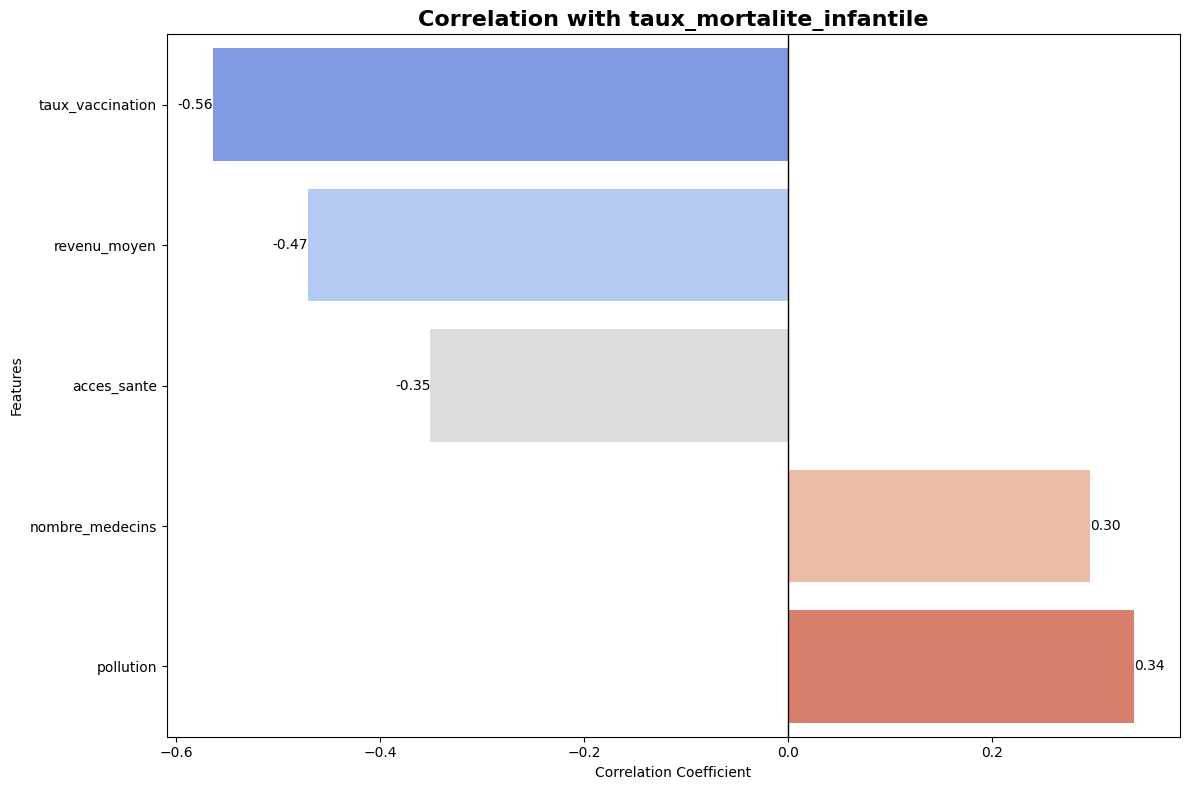

In [ ]:
# 3. correlation with target variable
target_col = 'taux_mortalite_infantile'

# Compute correlations
correlations = (
    data.corr(numeric_only=True)[target_col]
    .drop(target_col)  # remove self-correlation
    .sort_values()
)

# Plot
plt.figure(figsize=(12, 8))

sns.barplot(
    x=correlations.values,
    y=correlations.index,
    hue=correlations.index,
    legend=False
)

# Add a vertical line at 0
plt.axvline(0, color='black', linewidth=1)

# Titles and labels
plt.title(f'Correlation with {target_col}', fontsize=16, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

# Add correlation values on bars
for i, value in enumerate(correlations.values):
    plt.text(
        value,
        i,
        f'{value:.2f}',
        va='center',
        ha='left' if value > 0 else 'right'
    )

plt.tight_layout()
plt.show()

In [ ]:
# key insights identified
# 1. Vaccination rate is the strongest protective factor against infant mortality (r = –0.56). Districts with higher coverage consistently show lower mortality rates. 
# 2. Average income is the second strongest negative correlate (r = –0.47), reflecting how socio-economic status drives access to nutrition, clean water, and healthcare. 
# 3. Healthcare access score also has a meaningful negative relationship (r = –0.35). Better access to medical facilities translates into lower mortality. 
# 4. Pollution (r = +0.34) and **number of doctors** (r = +0.30) show positive correlations with mortality — a counter-intuitive pattern that may indicate that areas with more recorded doctors are also more urbanised and industrialised, hence more polluted. 
# 5. **No outliers** were detected in any variable, and all distributions are approximately symmetric (|skewness| < 0.15). The dataset is clean and ready for regression or clustering tasks. 

# 6.In terms of policy implication,investing in vaccination campaigns and income-generating programmes would likely yield the greatest reductions in infant mortality, while pollution control remains an important complementary measure.